# Validate effective current fields along drifter tracks

Sample CMEMS effective currents (Eulerian + Stokes drift) along observed drifter
trajectories and compare model-predicted velocity against observed drifter
velocity. No forward simulation -- just field interpolation at drifter positions.

Validation is restricted to science periods extracted in notebook 00.

## Parameters

In [1]:
CSV_PATH = "data/drifters_science.csv"
EFFECTIVE_CURRENTS_PATH = "data/cmems/effective_currents.nc"
WAVE_PATH = "data/cmems/cmems_mod_bal_wav_anfc_PT1H-i.nc"
RESAMPLE_INTERVAL = "1h"

## Imports

In [2]:
import cartopy.crs as ccrs
import cartopy.io.img_tiles as cimgt
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

## Load and resample science observations

In [3]:
# CSV_PATH points to drifters_science.csv, which contains only science-period
# positions (extracted in notebook 00). No additional filtering needed.
df_raw = pd.read_csv(CSV_PATH, parse_dates=["date_UTC"])
df_raw = df_raw.rename(columns={"Latitude": "lat", "Longitude": "lon"})

# Resample each drifter to hourly, keeping nearest observation
frames = []
for name, grp in df_raw.groupby("D_number"):
    grp = grp.set_index("date_UTC").sort_index()
    grp_hourly = grp[["lat", "lon"]].resample(RESAMPLE_INTERVAL).nearest()
    grp_hourly["D_number"] = name
    frames.append(grp_hourly)

df = pd.concat(frames).reset_index().rename(columns={"date_UTC": "time"})
df = df.dropna(subset=["lat", "lon"])
print(f"Resampled observations (science periods only): {len(df)} rows, {df['D_number'].nunique()} drifters")
df.head()

Resampled observations (science periods only): 1351 rows, 6 drifters


,time,lat,lon,D_number
0,2023-04-24 08:00:00,54.509274,10.194950,D298
1,2023-04-24 09:00:00,54.512231,10.201703,D298
2,2023-04-24 10:00:00,54.511483,10.209360,D298
3,2023-04-24 11:00:00,54.509781,10.217607,D298
4,2023-04-24 12:00:00,54.507590,10.224776,D298


## Load effective currents

In [4]:
ds = xr.open_dataset(EFFECTIVE_CURRENTS_PATH)
print(ds)
# Available depths
print("Depths:", ds.depth.values)

<xarray.Dataset> Size: 1GB
Dimensions:    (time: 336, depth: 5, latitude: 150, longitude: 143)
Coordinates:
  * time       (time) datetime64[ns] 3kB 2023-04-24 ... 2023-05-07T23:00:00
  * depth      (depth) float32 20B 0.5016 1.516 2.548 3.602 4.684
  * latitude   (latitude) float32 600B 53.51 53.52 53.54 ... 55.96 55.97 55.99
  * longitude  (longitude) float32 572B 9.042 9.069 9.097 ... 12.93 12.96 12.99
Data variables:
    U_eff      (time, depth, latitude, longitude) float64 288MB ...
    V_eff      (time, depth, latitude, longitude) float64 288MB ...
    uo         (time, depth, latitude, longitude) float32 144MB ...
    vo         (time, depth, latitude, longitude) float32 144MB ...
    u_stokes   (time, depth, latitude, longitude) float64 288MB ...
    v_stokes   (time, depth, latitude, longitude) float64 288MB ...
Attributes:
    description:  Effective current: Eulerian + Stokes drift profile
Depths: [0.5016462 1.5159924 2.548084  3.6022985 4.684081 ]


In [5]:
# Extrapolate onto land: rolling mean fills NaN coastal cells
# Apply along latitude, then longitude (width=3, min_periods=1)
ds_vars = ["U_eff", "V_eff", "uo", "vo", "u_stokes", "v_stokes"]
for _ in range(3):  # iterate to propagate further into land
    for var in ds_vars:
        filled = (
            ds[var]
            .rolling(latitude=3, center=True, min_periods=1).mean()
            .rolling(longitude=3, center=True, min_periods=1).mean()
        )
        ds[var] = ds[var].fillna(filled)

print(f"Extrapolated {ds_vars} onto land (3 passes, rolling width=3)")

Extrapolated ['U_eff', 'V_eff', 'uo', 'vo', 'u_stokes', 'v_stokes'] onto land (3 passes, rolling width=3)


## Interpolate fields to drifter positions

Interpolate U_eff, uo, vo at surface (~0.5 m) and drogue depth (3.0 m) along each drifter track.

In [ ]:
DEPTH_SURFACE = float(ds.depth.isel(depth=0))   # ~0.5 m
DEPTH_DROGUE = 3.0                           # interpolated to exactly 3 m

sampled_records = []

for name, grp in df.groupby("D_number"):
    grp = grp.sort_values("time").reset_index(drop=True)

    times = xr.DataArray(grp["time"].values, dims="points")
    lats = xr.DataArray(grp["lat"].values, dims="points")
    lons = xr.DataArray(grp["lon"].values, dims="points")

    interp_surf = ds[["U_eff", "V_eff", "uo", "vo"]].interp(
        time=times, latitude=lats, longitude=lons, depth=DEPTH_SURFACE,
        method="linear",
    )
    interp_drog = ds[["U_eff", "V_eff", "uo", "vo"]].interp(
        time=times, latitude=lats, longitude=lons, depth=DEPTH_DROGUE,
        method="linear",
    )

    rec = grp.copy()
    rec["U_eff_surf"] = interp_surf["U_eff"].values
    rec["V_eff_surf"] = interp_surf["V_eff"].values
    rec["uo_surf"] = interp_surf["uo"].values
    rec["vo_surf"] = interp_surf["vo"].values
    rec["U_eff_drog"] = interp_drog["U_eff"].values
    rec["V_eff_drog"] = interp_drog["V_eff"].values
    rec["uo_drog"] = interp_drog["uo"].values
    rec["vo_drog"] = interp_drog["vo"].values
    sampled_records.append(rec)

df_sampled = pd.concat(sampled_records).reset_index(drop=True)
print(f"Sampled dataset: {len(df_sampled)} rows")
print(f"Surface depth: {DEPTH_SURFACE:.2f} m, drogue depth: {DEPTH_DROGUE:.1f} m")
df_sampled.head()

## Compute observed drift speed

Estimate observed speed from consecutive hourly positions using the haversine formula.

In [7]:
def haversine_speed(lats, lons, times):
    """Compute speed in m/s from arrays of lat, lon (degrees) and times (datetime64)."""
    R = 6371e3
    lat = np.deg2rad(lats.values)
    lon = np.deg2rad(lons.values)
    dt_s = np.diff(times.values.astype("datetime64[s]").astype(float))

    dlat = np.diff(lat)
    dlon = np.diff(lon)
    a = np.sin(dlat / 2) ** 2 + np.cos(lat[:-1]) * np.cos(lat[1:]) * np.sin(dlon / 2) ** 2
    dist = 2 * R * np.arcsin(np.sqrt(a))

    speed = np.where(dt_s > 0, dist / dt_s, np.nan)
    return np.concatenate([[np.nan], speed])


m_per_deg = 111120.0

obs_frames = []
for name, grp in df_sampled.groupby("D_number"):
    grp = grp.sort_values("time").reset_index(drop=True)
    grp["obs_speed"] = haversine_speed(grp["lat"], grp["lon"], grp["time"])

    # Observed U (eastward) and V (northward) from finite differences
    dt_s = grp["time"].diff().dt.total_seconds()
    grp["obs_u"] = grp["lon"].diff() * m_per_deg * np.cos(np.deg2rad(grp["lat"])) / dt_s
    grp["obs_v"] = grp["lat"].diff() * m_per_deg / dt_s
    obs_frames.append(grp)

df_sampled = pd.concat(obs_frames).reset_index(drop=True)

# Model speed magnitudes
df_sampled["eff_speed_surf"] = np.sqrt(df_sampled["U_eff_surf"]**2 + df_sampled["V_eff_surf"]**2)
df_sampled["eff_speed_drog"] = np.sqrt(df_sampled["U_eff_drog"]**2 + df_sampled["V_eff_drog"]**2)
df_sampled["euler_speed_surf"] = np.sqrt(df_sampled["uo_surf"]**2 + df_sampled["vo_surf"]**2)
df_sampled["euler_speed_drog"] = np.sqrt(df_sampled["uo_drog"]**2 + df_sampled["vo_drog"]**2)

print(df_sampled[["obs_speed", "eff_speed_surf", "eff_speed_drog", "euler_speed_surf", "euler_speed_drog"]].describe())

         obs_speed  eff_speed_surf  eff_speed_drog  euler_speed_surf  \
count  1345.000000     1351.000000     1351.000000       1351.000000   
mean      0.184378        0.196484        0.142576          0.145285   
std       0.134885        0.126467        0.110845          0.109387   
min       0.000000        0.006317        0.003598          0.005588   
25%       0.100432        0.103109        0.073791          0.079916   
50%       0.153481        0.172939        0.110734          0.114189   
75%       0.219255        0.252381        0.174491          0.178178   
max       1.001339        0.791125        0.799918          0.802026   

       euler_speed_drog  
count       1351.000000  
mean           0.135753  
std            0.107960  
min            0.001237  
25%            0.072438  
50%            0.105505  
75%            0.162422  
max            0.800897  


## Along-track speed comparison

Time series of observed drift speed versus model effective current speed (surface and drogue depth) per drifter.

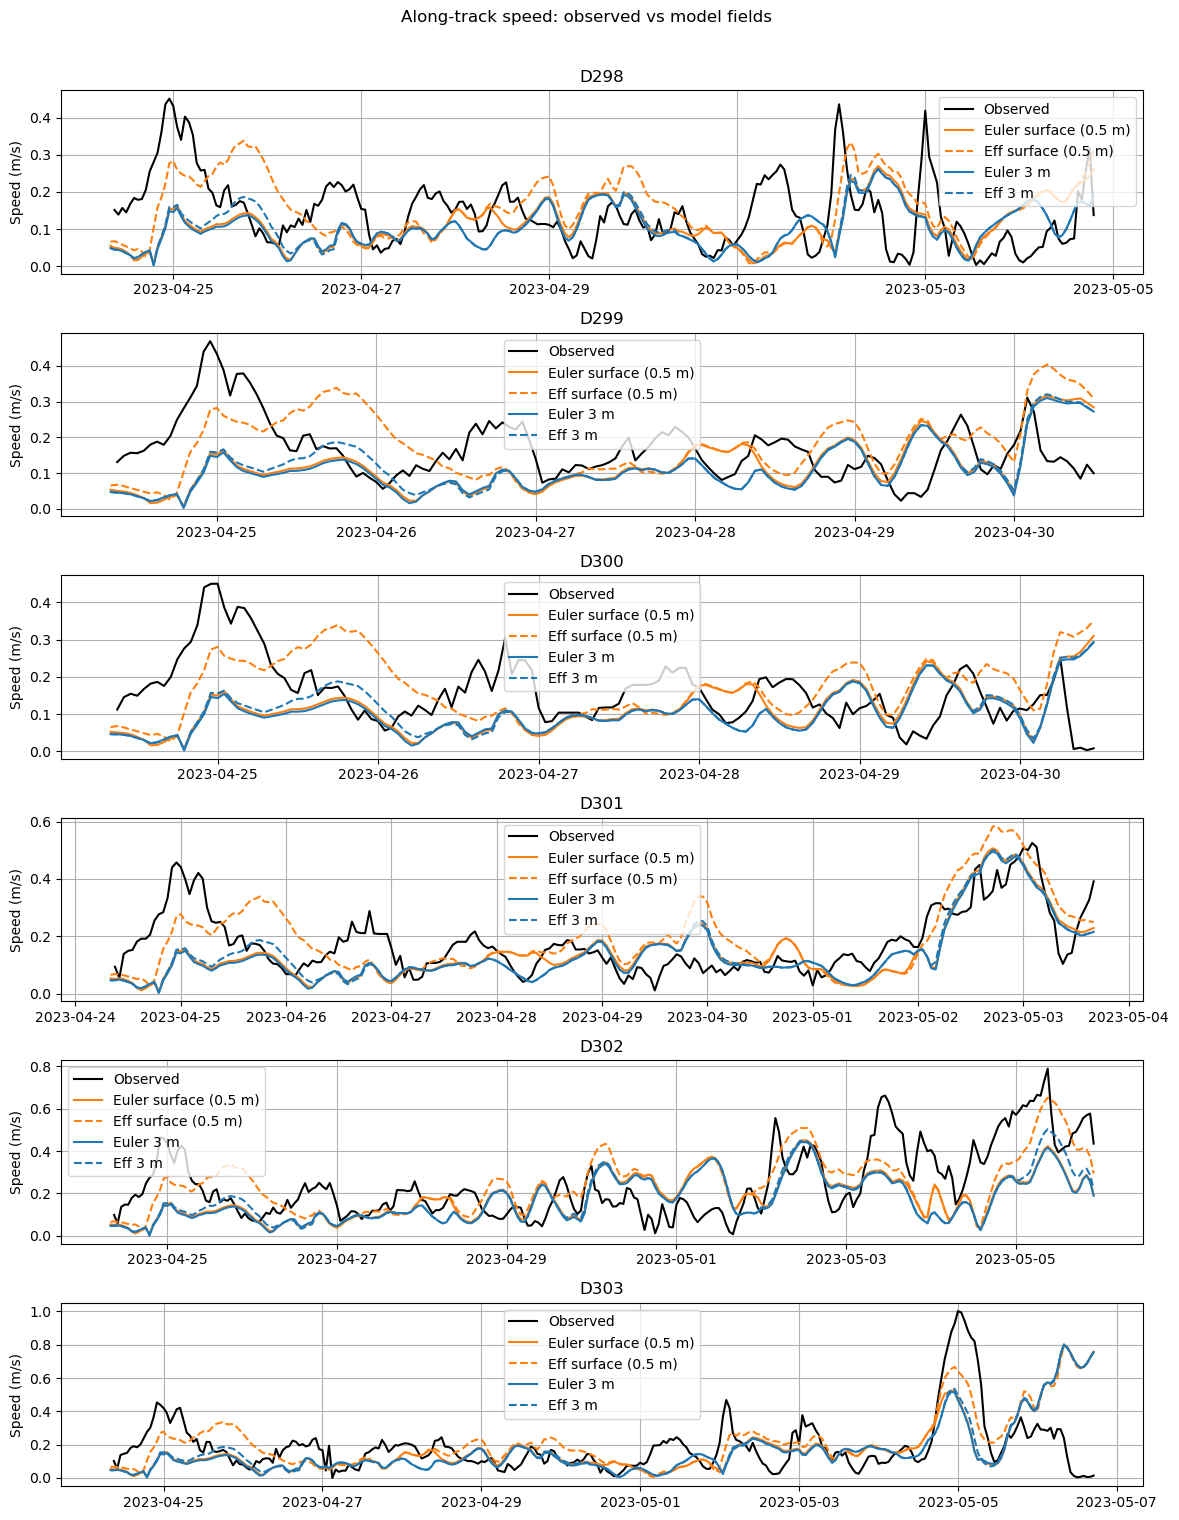

In [8]:
drifter_ids = sorted(df_sampled["D_number"].unique())
n = len(drifter_ids)

fig, axes = plt.subplots(n, 1, figsize=(12, 2.5 * n), sharex=False)
if n == 1:
    axes = [axes]

for ax, did in zip(axes, drifter_ids):
    sub = df_sampled[df_sampled["D_number"] == did].sort_values("time")
    ax.plot(sub["time"], sub["obs_speed"], color="black", label="Observed")
    ax.plot(sub["time"], sub["euler_speed_surf"], color="C1", label=f"Euler surface ({DEPTH_SURFACE:.1f} m)")
    ax.plot(sub["time"], sub["eff_speed_surf"], color="C1", ls="--", label=f"Eff surface ({DEPTH_SURFACE:.1f} m)")
    ax.plot(sub["time"], sub["euler_speed_drog"], color="C0", label=f"Euler {DEPTH_DROGUE:.0f} m")
    ax.plot(sub["time"], sub["eff_speed_drog"], color="C0", ls="--", label=f"Eff {DEPTH_DROGUE:.0f} m")
    ax.set_ylabel("Speed (m/s)")
    ax.set_title(did)
    ax.grid()
    ax.legend(loc=0)

fig.suptitle("Along-track speed: observed vs model fields", y=1.01)
plt.tight_layout()
plt.show()

## Along-track U/V component comparison

Eastward (U) and northward (V) velocity components per drifter: observed from finite differences vs model fields.

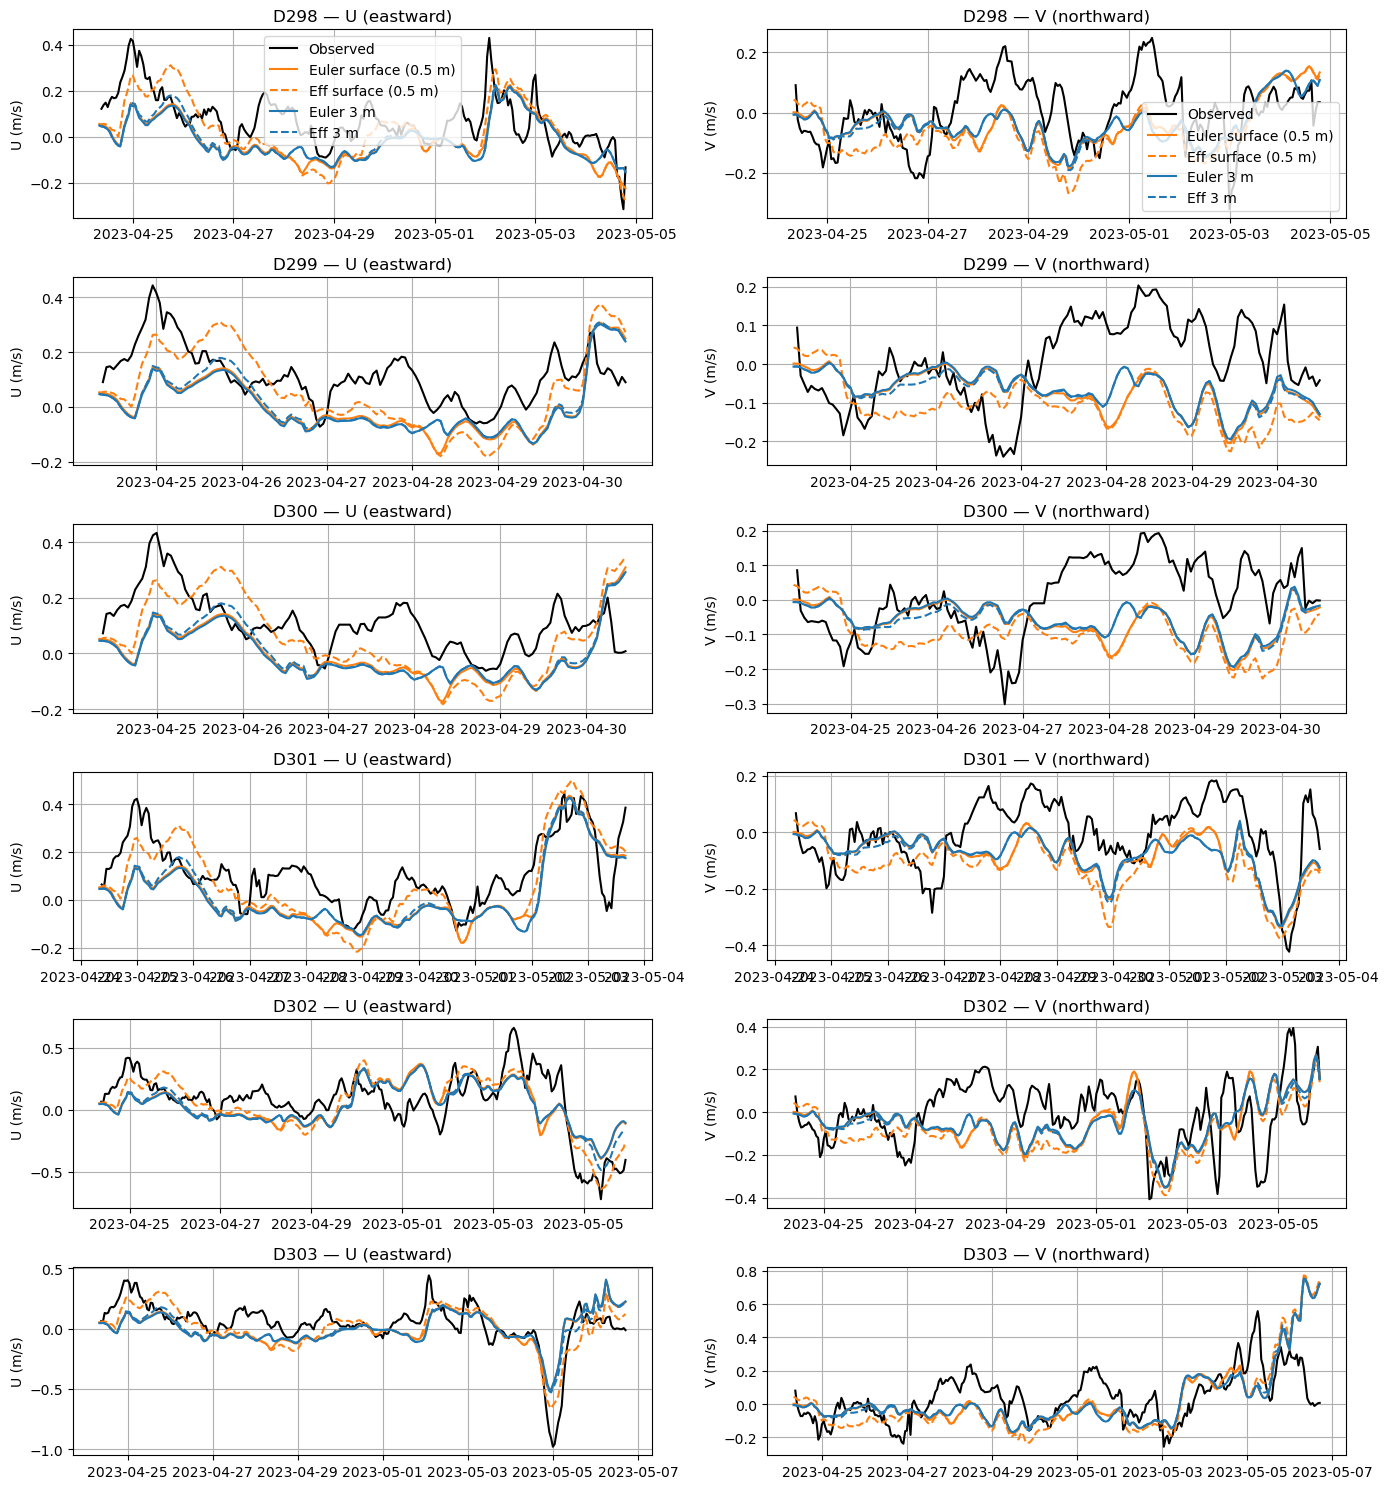

In [9]:
fig, axes = plt.subplots(n, 2, figsize=(14, 2.5 * n), sharex=False)

for i, did in enumerate(drifter_ids):
    sub = df_sampled[df_sampled["D_number"] == did].sort_values("time")
    ax_u, ax_v = axes[i, 0], axes[i, 1]

    for ax, obs_col, model_pairs, component in [
        (ax_u, "obs_u",
         [("uo_surf", "U_eff_surf", f"surface ({DEPTH_SURFACE:.1f} m)", "C1"),
          ("uo_drog", "U_eff_drog", f"{DEPTH_DROGUE:.0f} m", "C0")],
         "U (m/s)"),
        (ax_v, "obs_v",
         [("vo_surf", "V_eff_surf", f"surface ({DEPTH_SURFACE:.1f} m)", "C1"),
          ("vo_drog", "V_eff_drog", f"{DEPTH_DROGUE:.0f} m", "C0")],
         "V (m/s)"),
    ]:
        ax.plot(sub["time"], sub[obs_col], color="black", label="Observed")
        for euler_col, eff_col, label, color in model_pairs:
            ax.plot(sub["time"], sub[euler_col], color=color, label=f"Euler {label}")
            ax.plot(sub["time"], sub[eff_col], color=color, ls="--", label=f"Eff {label}")
        ax.grid()
        ax.set_ylabel(component)
        if i == 0:
            ax.legend(loc=0)

    ax_u.set_title(f"{did} — U (eastward)")
    ax_v.set_title(f"{did} — V (northward)")

plt.tight_layout()
plt.show()